<a href="https://colab.research.google.com/github/pranavipujari/Quantitative-Portfolio-Optimizer/blob/main/notebooks/Portfolio_Analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance seaborn


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
TICKERS = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]
START_DATE = "2021-01-01"
END_DATE   = "2024-01-01"
RISK_FREE_RATE = 0.04
NUM_PORTFOLIOS = 4000
INITIAL_INVESTMENT = 10000

In [ ]:
print("\n📥  Downloading stock data from Yahoo Finance...")
print(f"    Stocks : {', '.join(TICKERS)}")
print(f"    Period : {START_DATE}  →  {END_DATE}\n")


📥  Downloading stock data from Yahoo Finance...
    Stocks : AAPL, MSFT, TSLA, GOOGL, AMZN
    Period : 2021-01-01  →  2024-01-01



In [ ]:
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False)
prices = raw_data["Close"]

In [ ]:
prices = prices.dropna()

print(f"✅  Got {len(prices)} trading days of data for {len(TICKERS)} stocks.\n")
print("--- First 5 rows of price data ($/share) ---")
print(prices.head().round(2))
print()


✅  Got 753 trading days of data for 5 stocks.

--- First 5 rows of price data ($/share) ---
Ticker        AAPL    AMZN  GOOGL    MSFT    TSLA
Date                                             
2021-01-04  125.74  159.33  85.60  208.41  243.26
2021-01-05  127.30  160.93  86.29  208.61  245.04
2021-01-06  123.01  156.92  85.44  203.20  251.99
2021-01-07  127.21  158.11  87.99  208.98  272.01
2021-01-08  128.31  159.13  89.15  210.25  293.34



In [ ]:
daily_returns = prices.pct_change().dropna()

print("--- Daily returns (first 3 rows, as decimals) ---")
print(daily_returns.head(3).round(4))
print("  (0.02 means +2% that day, -0.03 means -3%)\n")


--- Daily returns (first 3 rows, as decimals) ---
Ticker        AAPL    AMZN   GOOGL    MSFT    TSLA
Date                                              
2021-01-05  0.0124  0.0100  0.0081  0.0010  0.0073
2021-01-06 -0.0337 -0.0249 -0.0099 -0.0259  0.0284
2021-01-07  0.0341  0.0076  0.0299  0.0285  0.0794
  (0.02 means +2% that day, -0.03 means -3%)



In [ ]:
TRADING_DAYS = 252
annual_return = daily_returns.mean() * TRADING_DAYS
annual_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)



In [ ]:
sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility
summary = pd.DataFrame({
    "Annual Return (%)":     (annual_return * 100).round(2),
    "Annual Volatility (%)": (annual_volatility * 100).round(2),
    "Sharpe Ratio":           sharpe_ratio.round(3)
}).sort_values("Sharpe Ratio", ascending=False)

print("=" * 55)
print("   PER-STOCK SUMMARY")
print("=" * 55)
print(summary.to_string())
print("=" * 55)
print()

   PER-STOCK SUMMARY
        Annual Return (%)  Annual Volatility (%)  Sharpe Ratio
Ticker                                                        
MSFT                23.08                  27.83         0.685
GOOGL               21.17                  31.74         0.541
AAPL                17.76                  27.80         0.495
TSLA                18.02                  58.89         0.238
AMZN                 5.39                  37.40         0.037



In [ ]:
print(f"🎲  Running Monte Carlo simulation ({NUM_PORTFOLIOS:,} random portfolios)...")


🎲  Running Monte Carlo simulation (4,000 random portfolios)...


In [ ]:
cov_matrix = daily_returns.cov() * TRADING_DAYS

n = len(TICKERS)

In [ ]:
port_returns    = np.zeros(NUM_PORTFOLIOS)
port_volatility = np.zeros(NUM_PORTFOLIOS)
port_sharpe     = np.zeros(NUM_PORTFOLIOS)
all_weights     = np.zeros((NUM_PORTFOLIOS, n))

for i in range(NUM_PORTFOLIOS):

    weights = np.random.dirichlet(np.ones(n))
    all_weights[i] = weights


    p_return = np.dot(weights, annual_return)


    p_vol = np.sqrt(weights.T @ cov_matrix.values @ weights)


    p_sharpe = (p_return - RISK_FREE_RATE) / p_vol

    port_returns[i]    = p_return
    port_volatility[i] = p_vol
    port_sharpe[i]     = p_sharpe


best_idx     = port_sharpe.argmax()
best_weights = all_weights[best_idx]
best_return  = port_returns[best_idx]
best_vol     = port_volatility[best_idx]
best_sharpe  = port_sharpe[best_idx]


min_vol_idx     = port_volatility.argmin()
min_vol_weights = all_weights[min_vol_idx]

print("✅  Simulation complete!\n")
print("=" * 55)
print("   OPTIMAL PORTFOLIO  (Maximum Sharpe Ratio)")
print("=" * 55)
for ticker, w in zip(TICKERS, best_weights):
    bar = "█" * int(w * 30)
    print(f"   {ticker:6s}  {w:5.1%}  {bar}")
print(f"\n   Sharpe Ratio  : {best_sharpe:.3f}")
print(f"   Annual Return : {best_return:.1%}")
print(f"   Annual Risk   : {best_vol:.1%}")
print("=" * 55)
print()


✅  Simulation complete!

   OPTIMAL PORTFOLIO  (Maximum Sharpe Ratio)
   AAPL     1.3%  
   MSFT     0.1%  
   TSLA    15.1%  ████
   GOOGL   80.3%  ████████████████████████
   AMZN     3.2%  

   Sharpe Ratio  : 0.680
   Annual Return : 22.5%
   Annual Risk   : 27.3%



In [ ]:
portfolio_daily_returns = (daily_returns * best_weights).sum(axis=1)

portfolio_growth = INITIAL_INVESTMENT * (1 + portfolio_daily_returns).cumprod()

individual_growth = INITIAL_INVESTMENT * (1 + daily_returns).cumprod()

In [ ]:
print("🎨  Drawing charts...")


🎨  Drawing charts...


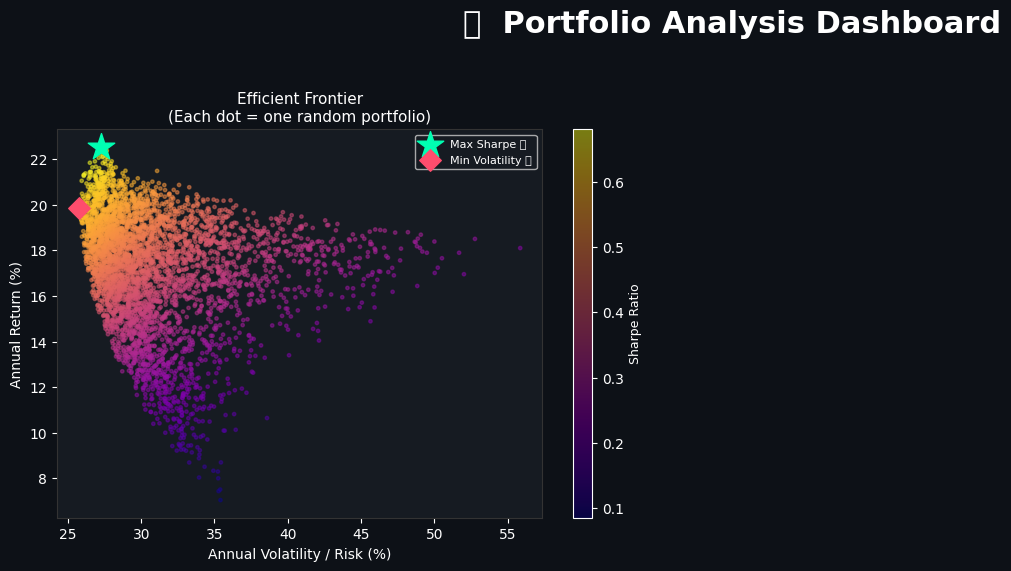

In [ ]:
plt.style.use("dark_background")
sns.set_palette("husl")

ACCENT   = "#00FFB2"
ACCENT2  = "#FF4D6D"
BG_COLOR = "#0D1117"
CARD_BG  = "#161B22"

fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
fig.suptitle("📊  Portfolio Analysis Dashboard",
             fontsize=22, fontweight="bold", color="white", y=0.98)


gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)


ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(CARD_BG)



sc = ax1.scatter(
    port_volatility * 100,
    port_returns * 100,
    c=port_sharpe,
    cmap="plasma",
    alpha=0.5,
    s=6
)


cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label("Sharpe Ratio", color="white", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")


ax1.scatter(best_vol * 100, best_return * 100,
            color=ACCENT, marker="*", s=400, zorder=5, label="Max Sharpe ⭐")

ax1.scatter(port_volatility[min_vol_idx] * 100, port_returns[min_vol_idx] * 100,
            color=ACCENT2, marker="D", s=120, zorder=5, label="Min Volatility 🔵")

ax1.set_xlabel("Annual Volatility / Risk (%)", color="white")
ax1.set_ylabel("Annual Return (%)", color="white")
ax1.set_title("Efficient Frontier\n(Each dot = one random portfolio)", color="white", fontsize=11)
ax1.tick_params(colors="white")
ax1.legend(fontsize=8, facecolor=CARD_BG, labelcolor="white")
for spine in ax1.spines.values():
    spine.set_edgecolor("#333")

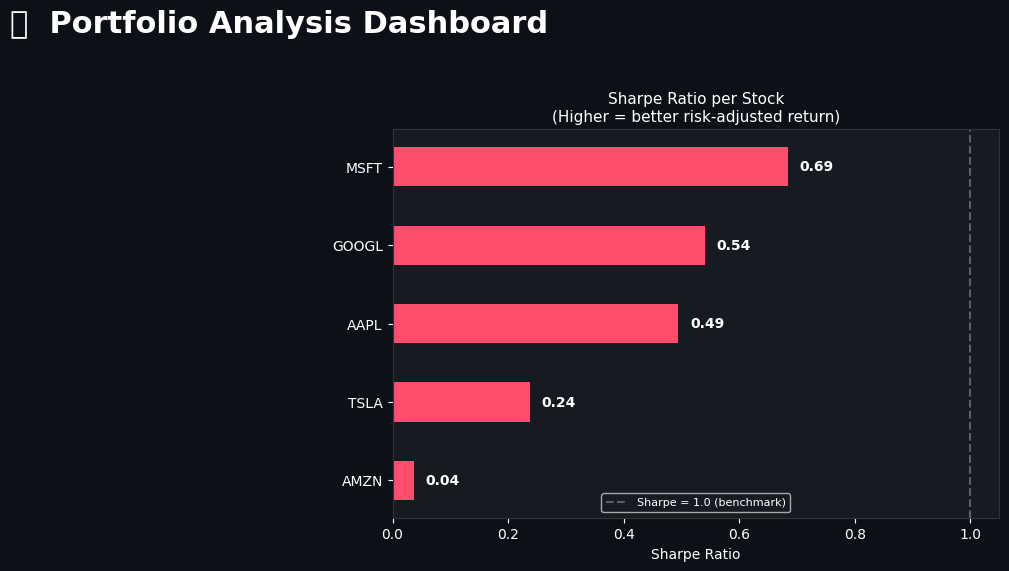

In [ ]:
plt.style.use("dark_background")
sns.set_palette("husl")

ACCENT   = "#00FFB2"
ACCENT2  = "#FF4D6D"
BG_COLOR = "#0D1117"
CARD_BG  = "#161B22"

fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
fig.suptitle("📊  Portfolio Analysis Dashboard",
             fontsize=22, fontweight="bold", color="white", y=0.98)


gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD_BG)

sorted_summary = summary.sort_values("Sharpe Ratio", ascending=True)
colors = [ACCENT if s > 1.0 else ACCENT2 for s in sorted_summary["Sharpe Ratio"]]

bars = ax2.barh(sorted_summary.index, sorted_summary["Sharpe Ratio"],
                color=colors, edgecolor="none", height=0.5)


for bar, val in zip(bars, sorted_summary["Sharpe Ratio"]):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", color="white", fontsize=10, fontweight="bold")

ax2.axvline(x=1.0, color="white", linestyle="--", alpha=0.3, label="Sharpe = 1.0 (benchmark)")
ax2.set_xlabel("Sharpe Ratio", color="white")
ax2.set_title("Sharpe Ratio per Stock\n(Higher = better risk-adjusted return)", color="white", fontsize=11)
ax2.tick_params(colors="white")
ax2.legend(fontsize=8, facecolor=CARD_BG, labelcolor="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#333")

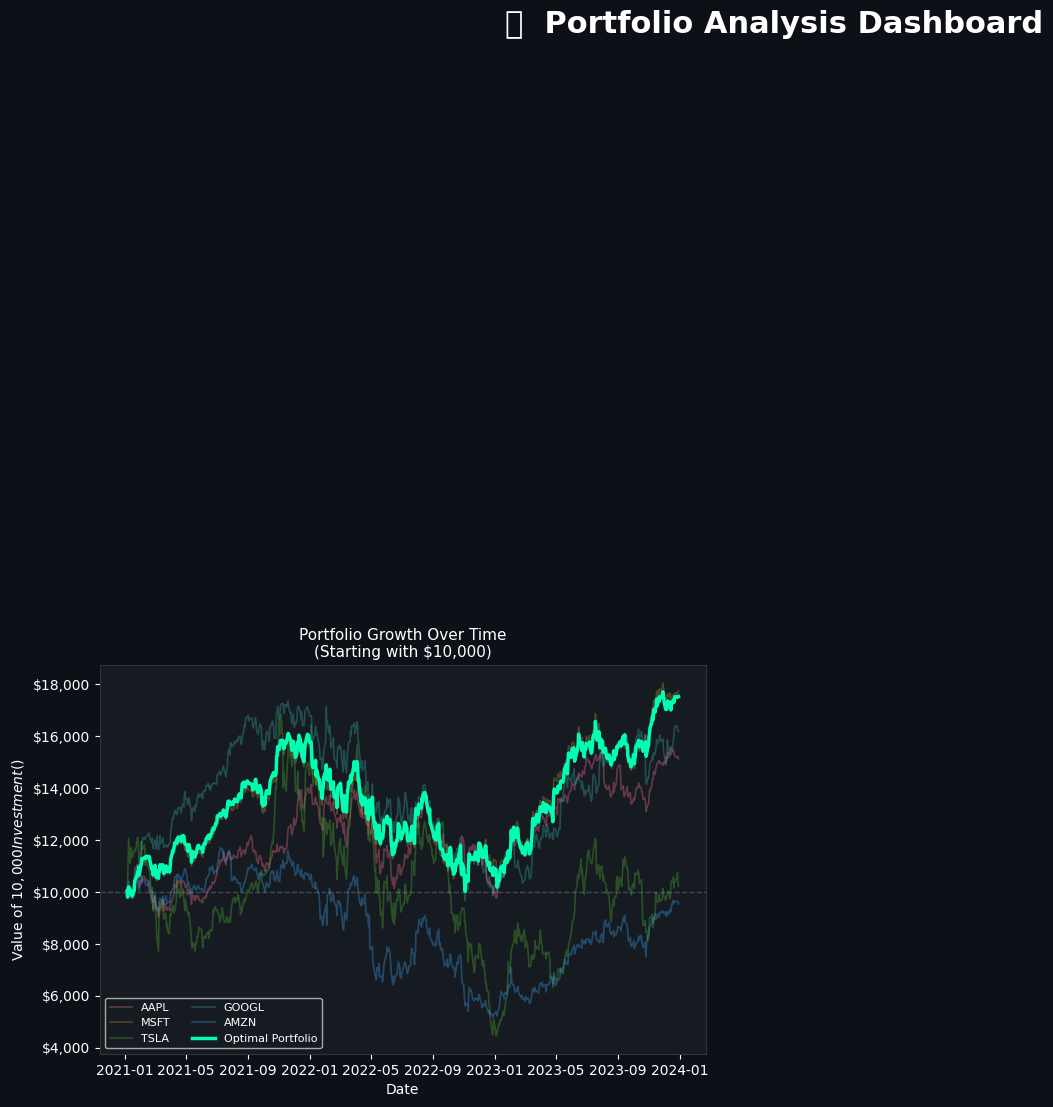

In [ ]:
plt.style.use("dark_background")
sns.set_palette("husl")

ACCENT   = "#00FFB2"
ACCENT2  = "#FF4D6D"
BG_COLOR = "#0D1117"
CARD_BG  = "#161B22"

fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
fig.suptitle("📊  Portfolio Analysis Dashboard",
             fontsize=22, fontweight="bold", color="white", y=0.98)


gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(CARD_BG)


for ticker in TICKERS:
    ax3.plot(individual_growth.index, individual_growth[ticker],
             alpha=0.35, linewidth=1.2, label=ticker)


ax3.plot(portfolio_growth.index, portfolio_growth,
         color=ACCENT, linewidth=2.5, label="Optimal Portfolio", zorder=5)

ax3.axhline(y=INITIAL_INVESTMENT, color="white", linestyle="--", alpha=0.2, linewidth=1)

ax3.set_xlabel("Date", color="white")
ax3.set_ylabel(f"Value of ${INITIAL_INVESTMENT:,} Investment ($)", color="white")
ax3.set_title(f"Portfolio Growth Over Time\n(Starting with ${INITIAL_INVESTMENT:,})", color="white", fontsize=11)
ax3.tick_params(colors="white")
ax3.legend(fontsize=8, facecolor=CARD_BG, labelcolor="white", ncol=2)
for spine in ax3.spines.values():
    spine.set_edgecolor("#333")


ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))


[None, None, None, None, None, None]

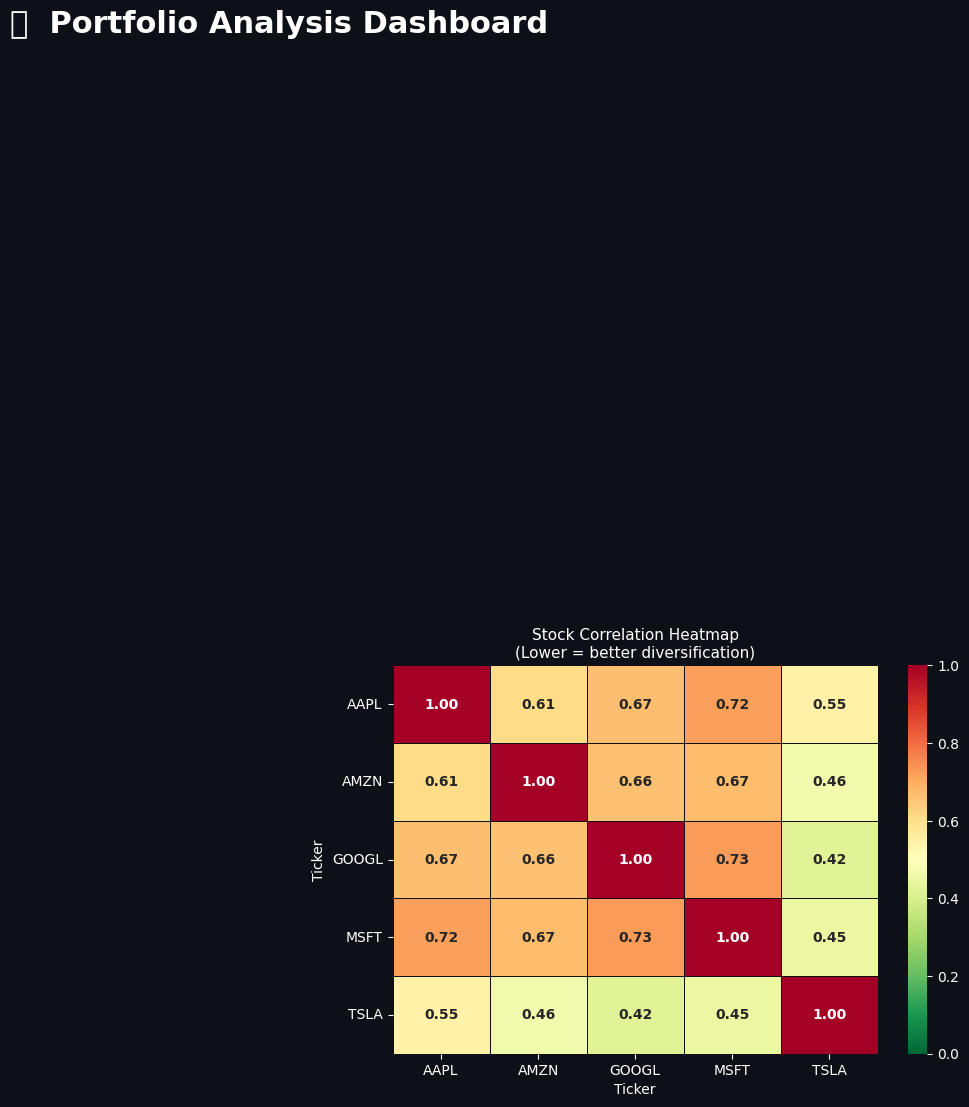

In [ ]:
plt.style.use("dark_background")
sns.set_palette("husl")

ACCENT   = "#00FFB2"
ACCENT2  = "#FF4D6D"
BG_COLOR = "#0D1117"
CARD_BG  = "#161B22"

fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
fig.suptitle("📊  Portfolio Analysis Dashboard",
             fontsize=22, fontweight="bold", color="white", y=0.98)


gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(CARD_BG)

corr = daily_returns.corr()


sns.heatmap(
    corr,
    ax=ax4,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor=BG_COLOR,
    annot_kws={"size": 10, "weight": "bold"}
)
ax4.set_title("Stock Correlation Heatmap\n(Lower = better diversification)", color="white", fontsize=11)
ax4.tick_params(colors="white")
ax4.set_xticklabels(ax4.get_xticklabels(), color="white")
ax4.set_yticklabels(ax4.get_yticklabels(), color="white", rotation=0)


cbar2 = ax4.collections[0].colorbar
cbar2.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="white")

In [ ]:
output_file = "portfolio_dashboard.png"
plt.savefig(output_file, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
print(f"💾  Chart saved as '{output_file}'")
plt.show()
print("\n🎉  Done! Check the charts and the printed summary above.")
print("    Feel free to change TICKERS, START_DATE, or INITIAL_INVESTMENT and rerun!\n")


💾  Chart saved as 'portfolio_dashboard.png'


<Figure size 640x480 with 0 Axes>


🎉  Done! Check the charts and the printed summary above.
    Feel free to change TICKERS, START_DATE, or INITIAL_INVESTMENT and rerun!

